In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


file_path = "diabetes.csv"
data = pd.read_csv(file_path)

data.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn
0,1000,203,82,56,3.6,4.31,Buckingham,46,female,62,121,medium,118,59,29,38,720
1,1001,165,97,24,6.9,4.44,Buckingham,29,female,64,218,large,112,68,46,48,360
2,1002,228,92,37,6.2,4.64,Buckingham,58,female,61,256,large,190,92,49,57,180
3,1003,78,93,12,6.5,4.63,Buckingham,67,male,67,119,large,110,50,33,38,480
4,1005,249,90,28,8.9,7.72,Buckingham,64,male,68,183,medium,138,80,44,41,300


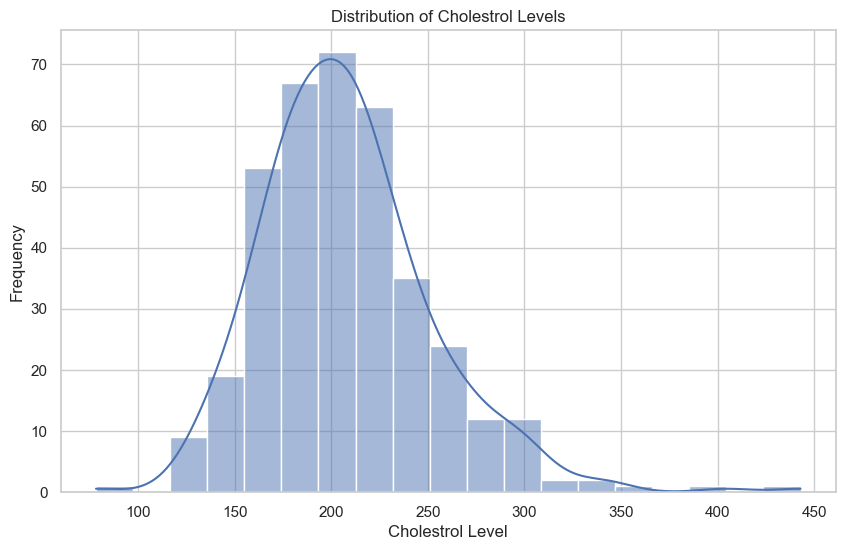

In [5]:
# Q1:

# a - distribution of cholestrol levels:
sns.set(style = "whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(data["chol"], bins = 19, kde = True) # altering bin size to change distribution
plt.title("Distribution of Cholestrol Levels")
plt.xlabel("Cholestrol Level")
plt.ylabel("Frequency")
plt.show()


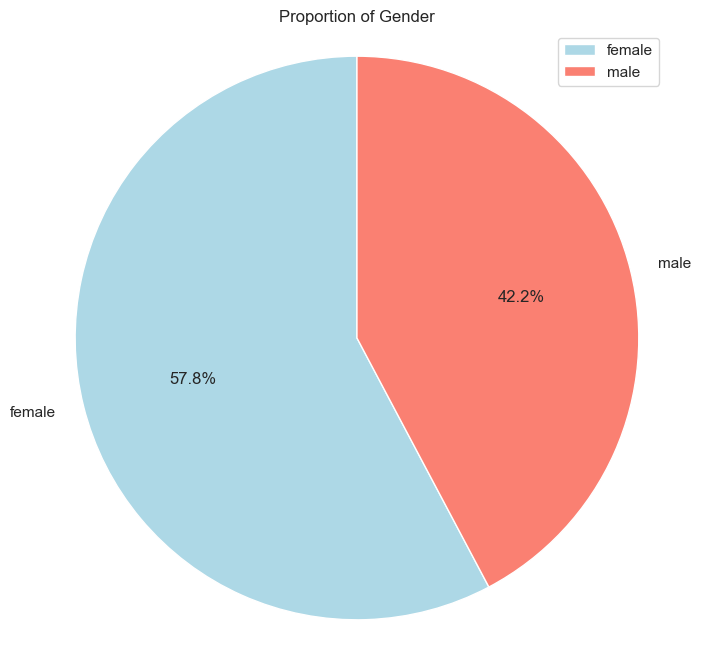

In [28]:
# b - proportions of gender:

gender_proportions = data["gender"].value_counts(normalize=True)
plt.figure(figsize=(8,8))
plt.pie(gender_proportions, labels = gender_proportions.index, startangle = 90,  autopct='%1.1f%%', colors = ("lightblue", "salmon"))
plt.title("Proportion of Gender")
plt.legend()
plt.axis("equal")
plt.show()

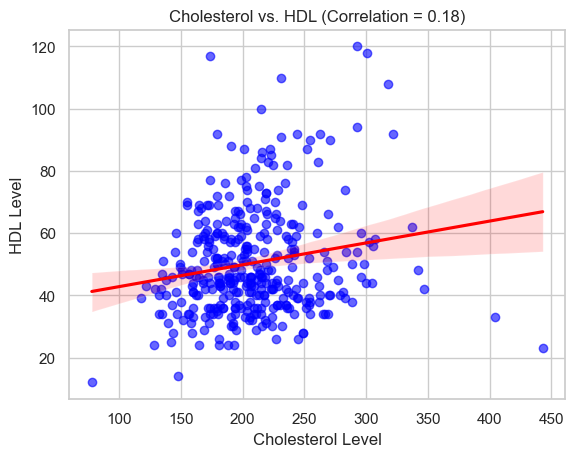

In [23]:
# c - associations - scatter plot of cholestrol level & hdl levels:
from scipy.stats import pearsonr

# calculate correlation coefficient
correlation, _ = pearsonr(data['chol'], data['hdl'])

# scatter plot with regression 
sns.regplot(x='chol', y='hdl', data=data, scatter_kws={'color': 'blue', 'alpha': 0.6}, 
            line_kws={'color': 'red'}, ci=95)

plt.xlabel('Cholesterol Level')
plt.ylabel('HDL Level')
plt.title(f'Cholesterol vs. HDL (Correlation = {correlation:.2f})')
plt.show()


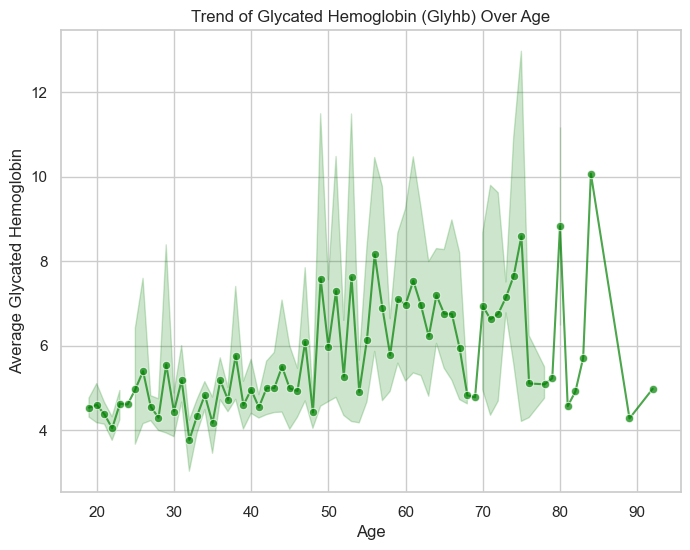

In [27]:
# d - trends - glycated hemoglobin over age:
import statsmodels.api as sm

# Line plot to visualize trend of glycated hemoglobin over age:
plt.figure(figsize=(8, 6))
sns.lineplot(x=data["age"], y=data["glyhb"], marker="o", color="green", alpha=0.7)
plt.title("Trend of Glycated Hemoglobin (Glyhb) Over Age")
plt.xlabel("Age")
plt.ylabel("Average Glycated Hemoglobin")
plt.grid(True)
plt.show()

/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_806/2136110987.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_pivot = heatmap_data.pivot_table(


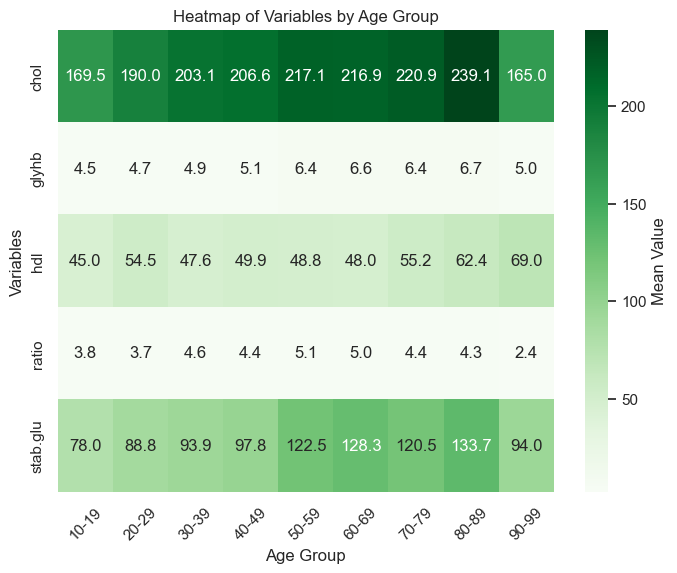

In [45]:
# e - heatmap - chol, stab.glu, hdl, ratio, and glyhb over age:

# convert to a data frame:
dataframe = pd.DataFrame(data)

# separating 'age' into bins:
bins = range(0, 101, 10)  # bins (0-100 in increments of 10)
labels = [f"{b}-{b+9}" for b in bins[:-1]]  # bins' labels
dataframe['age_group'] = pd.cut(dataframe['age'], bins=bins, labels=labels, right=False)


heatmap_data = dataframe.melt(
    id_vars=['age_group'], 
    value_vars=['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb'], 
    var_name='Variables', 
    value_name='Value'
)

heatmap_pivot = heatmap_data.pivot_table(
    index='Variables', 
    columns='age_group', 
    values='Value', 
    aggfunc="mean"
)


plt.figure(figsize=(8, 6)) 
sns.heatmap(heatmap_pivot, cmap="Greens", annot=True, fmt=".1f", cbar_kws={'label': 'Mean Value'})
plt.title('Heatmap of Variables by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Variables')
plt.xticks(rotation=45)  
plt.show()


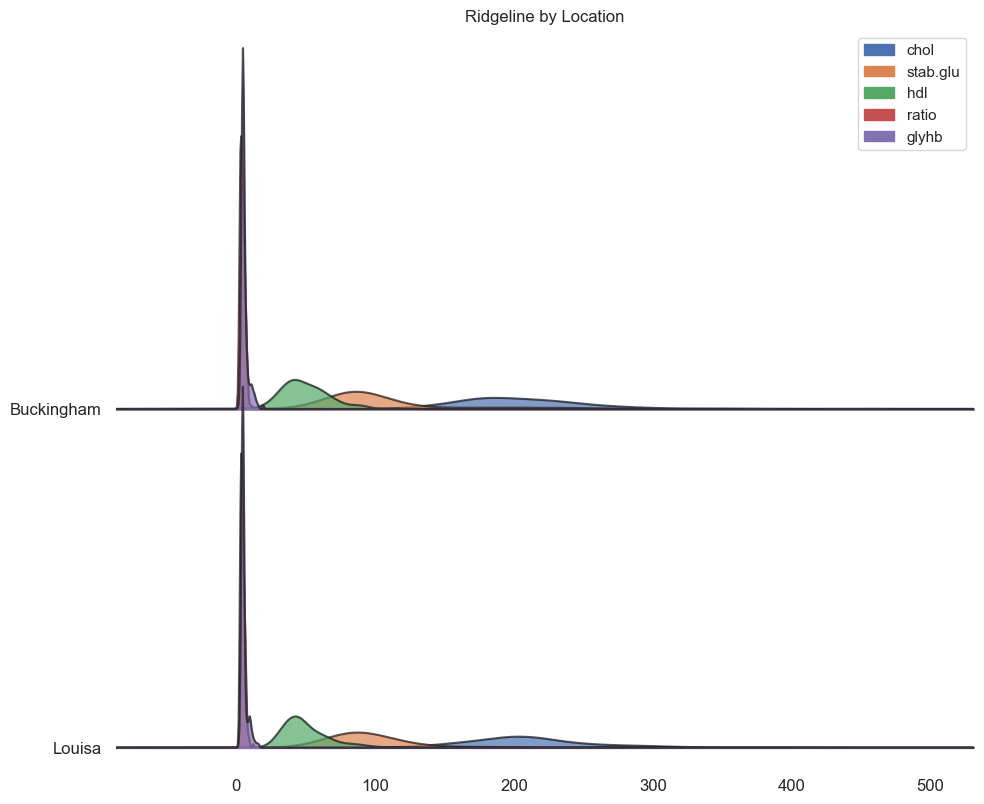

In [39]:
# f - ridgeline of chol, stab.glu, hdl, ratio, and glyhb by location - collective: 

from joypy import joyplot

fig, axes = joyplot(data, by="location", column=["chol", "stab.glu", "hdl", "ratio", "glyhb"],  ylim="own", figsize=(10, 8),alpha=0.7,overlap=0.7, legend = True)
plt.title("Ridgeline by Location")
plt.show()


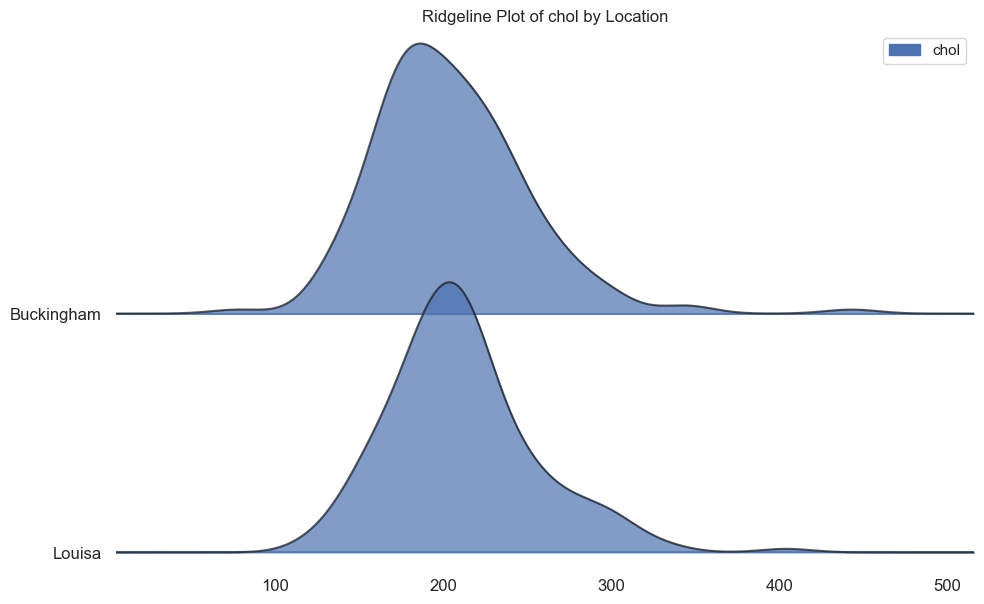

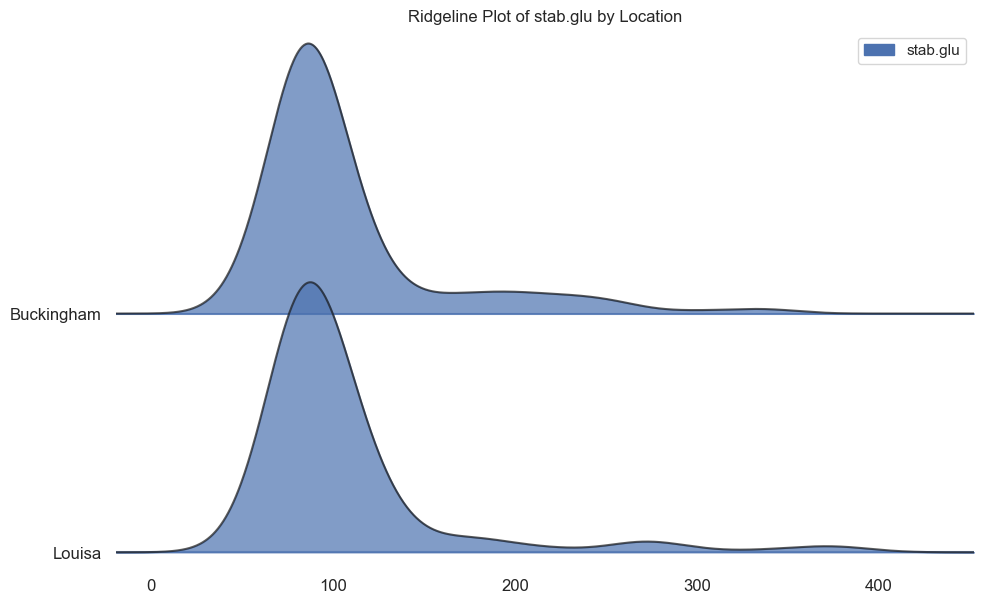

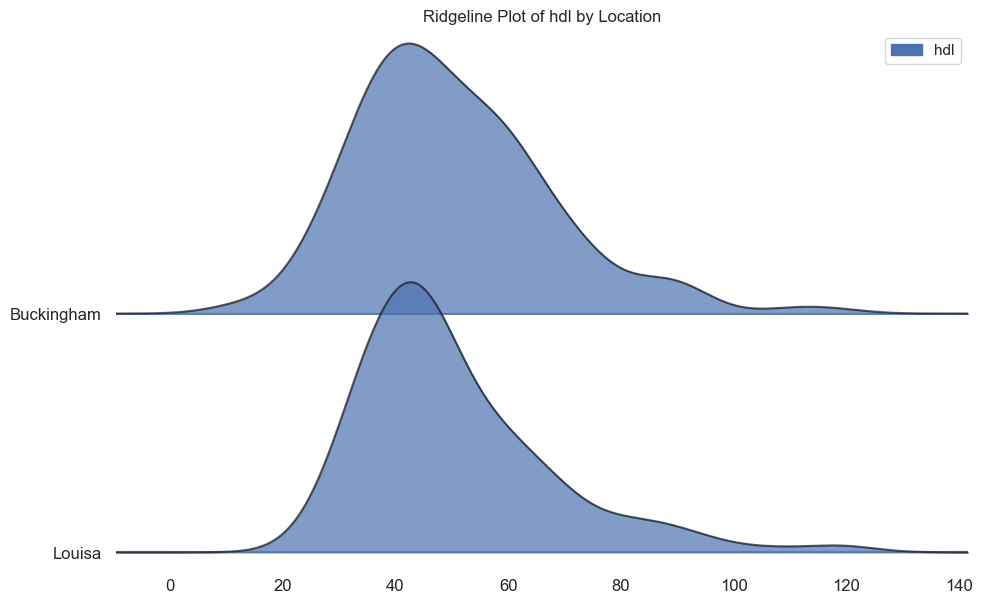

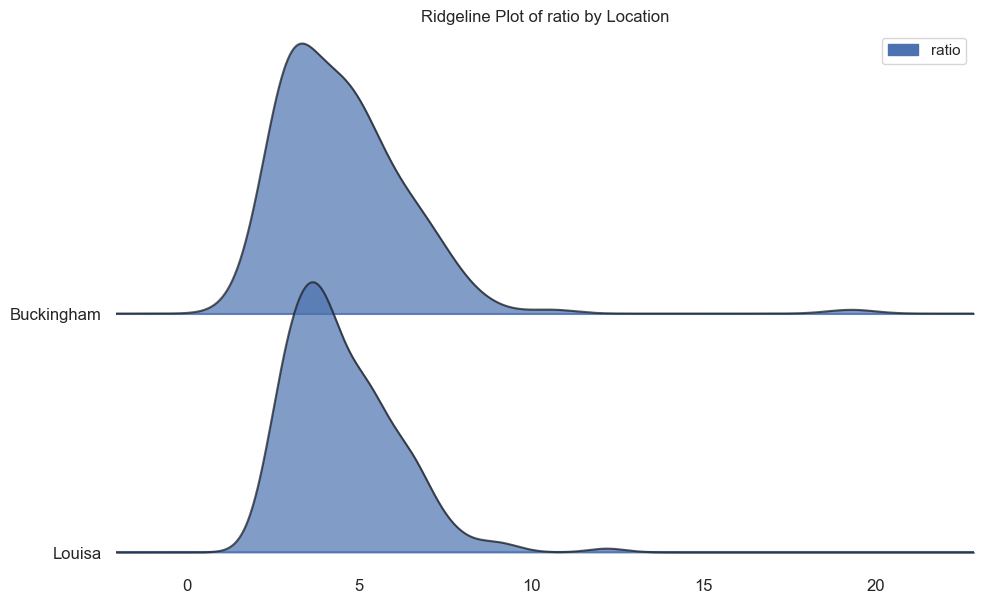

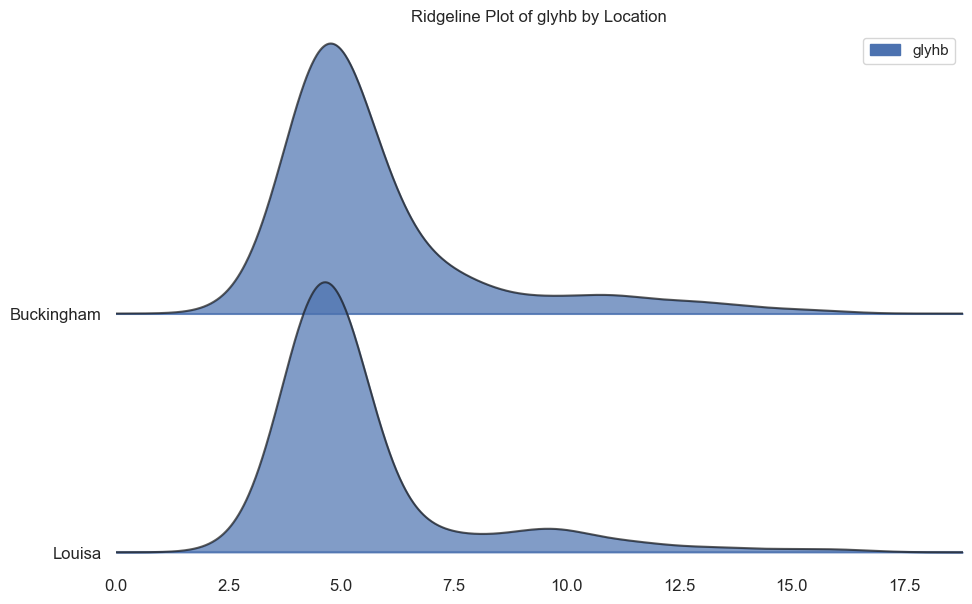

In [37]:
# f - ridgeline plot of chol, stab.glu, hdl, ratio, and glyhb by location - individual: 
from joypy import joyplot

# categories included in the plot:
measures = ["chol", "stab.glu", "hdl", "ratio", "glyhb"]

for measure in measures:
    fig, axes = joyplot(
        data,
        by="location",
        column=[measure],
        ylim="own",
        figsize=(10, 6),
        alpha=0.7,
        overlap=0.7,
        legend=True,
    )
    plt.title(f"Ridgeline Plot of {measure} by Location")
    plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_806/11319952.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')


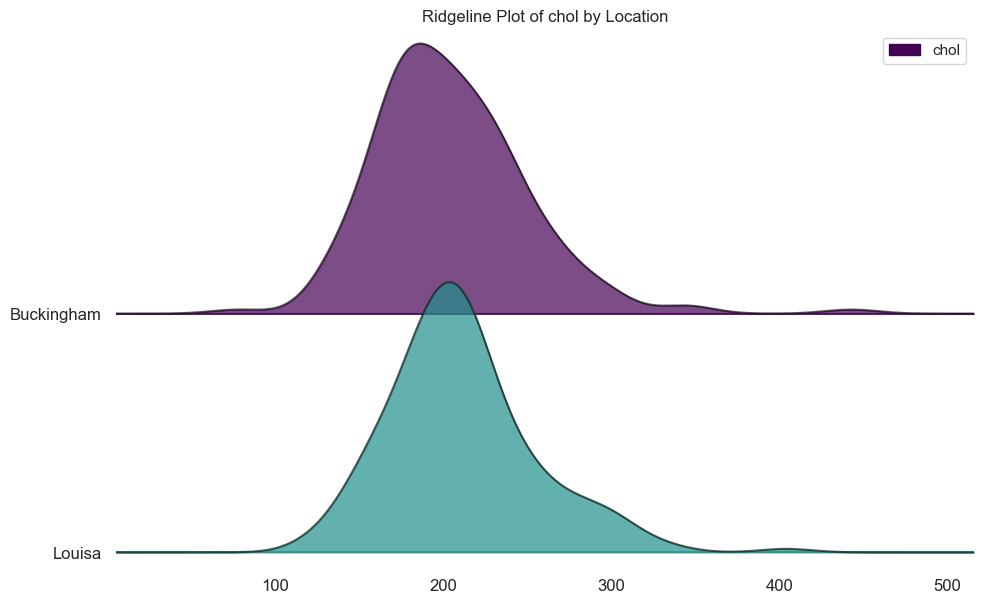

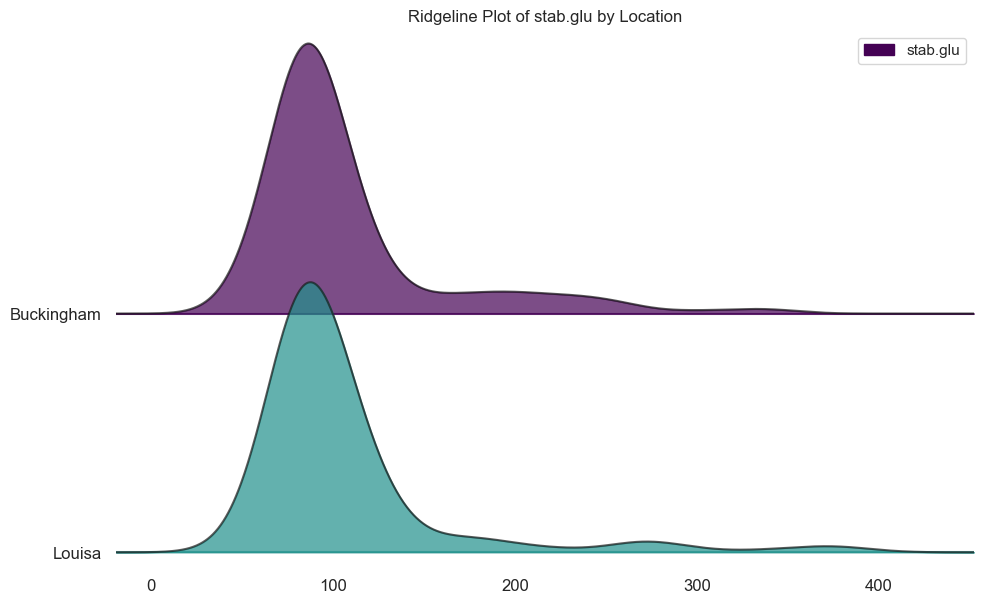

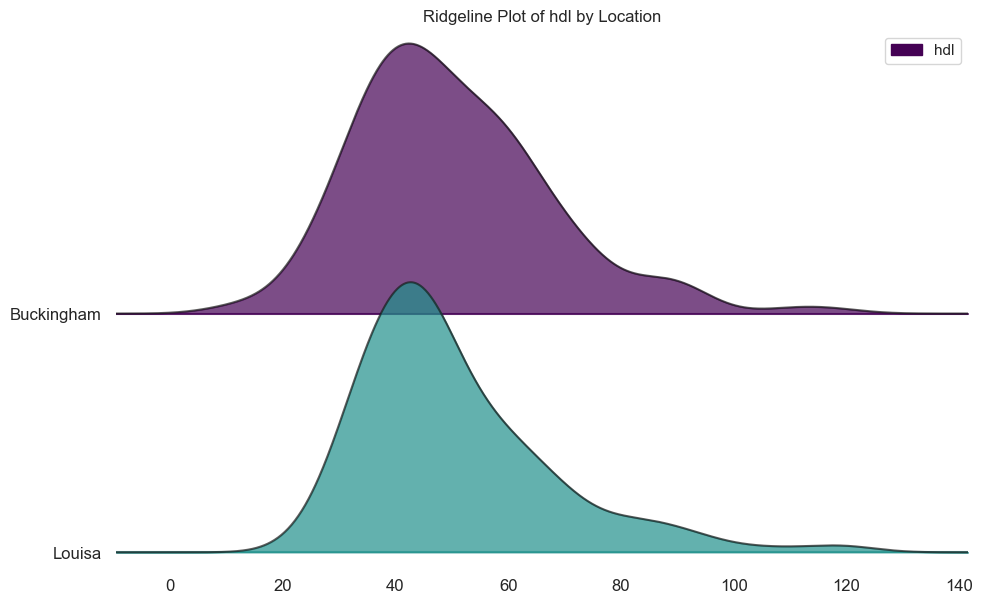

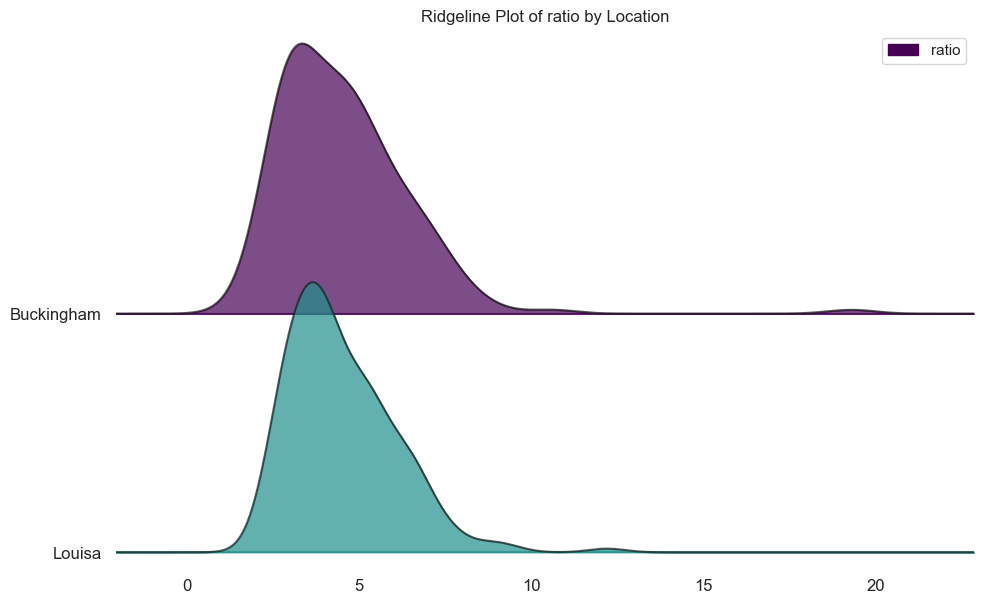

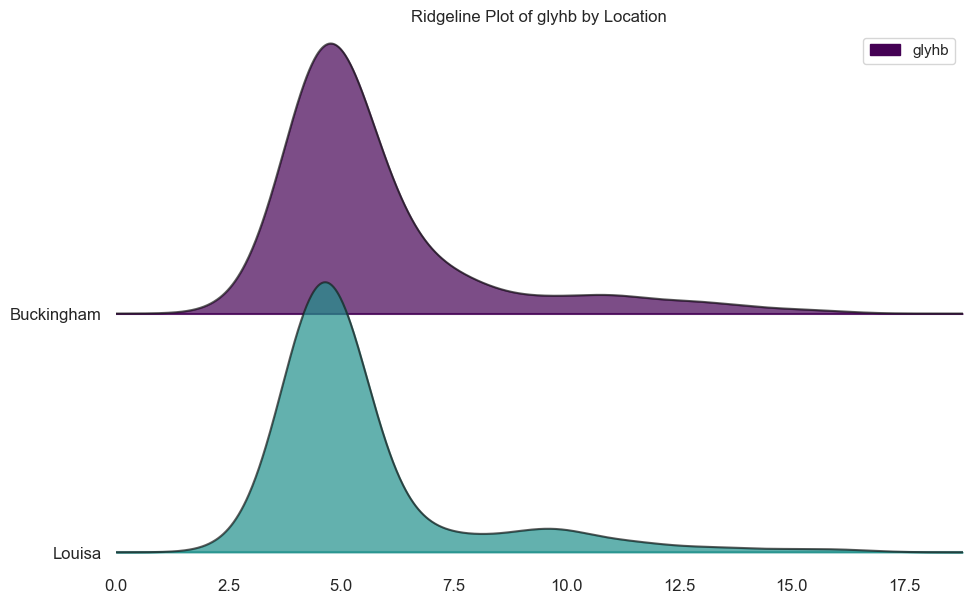

In [79]:
# # f - ridgeline plot of chol, stab.glu, hdl, ratio, and glyhb by location - individual with different colors: 
import matplotlib.cm as cm

# categories included in the plot:
measures = ["chol", "stab.glu", "hdl", "ratio", "glyhb"]

colormap = cm.get_cmap('viridis')  

for measure in measures:
    fig, axes = joyplot(
        data,
        by="location",
        column=[measure],
        ylim="own",
        figsize=(10, 6),
        alpha=0.7,
        overlap=0.7,
        legend=True,
        colormap=colormap  
    )
    plt.title(f"Ridgeline Plot of {measure} by Location")
    plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_806/3341049533.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # You can replace 'tab10' with another colormap


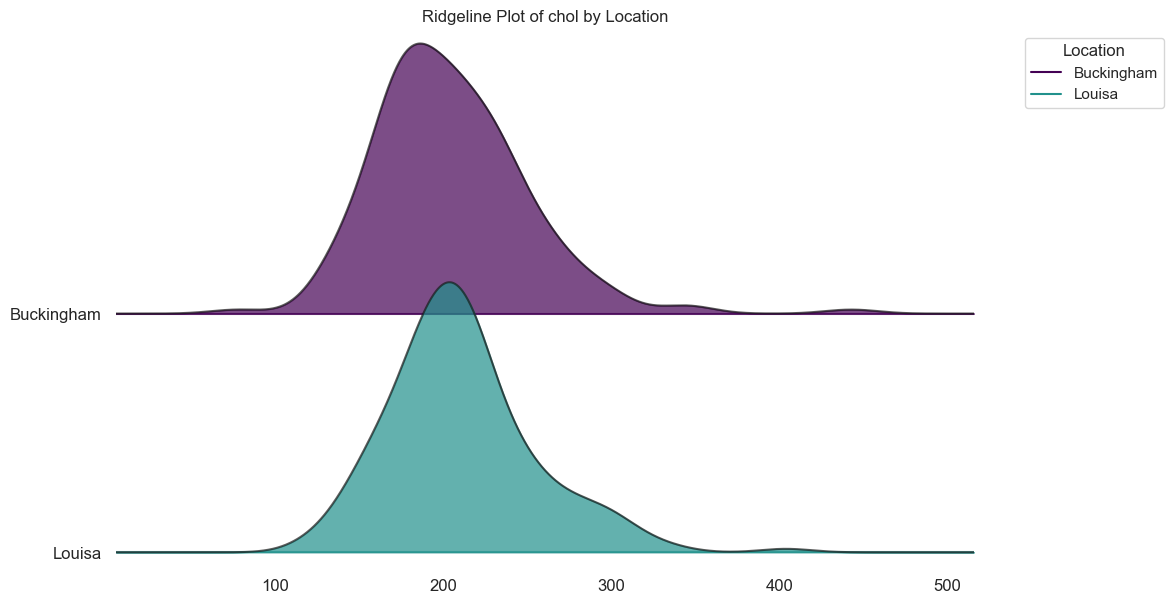

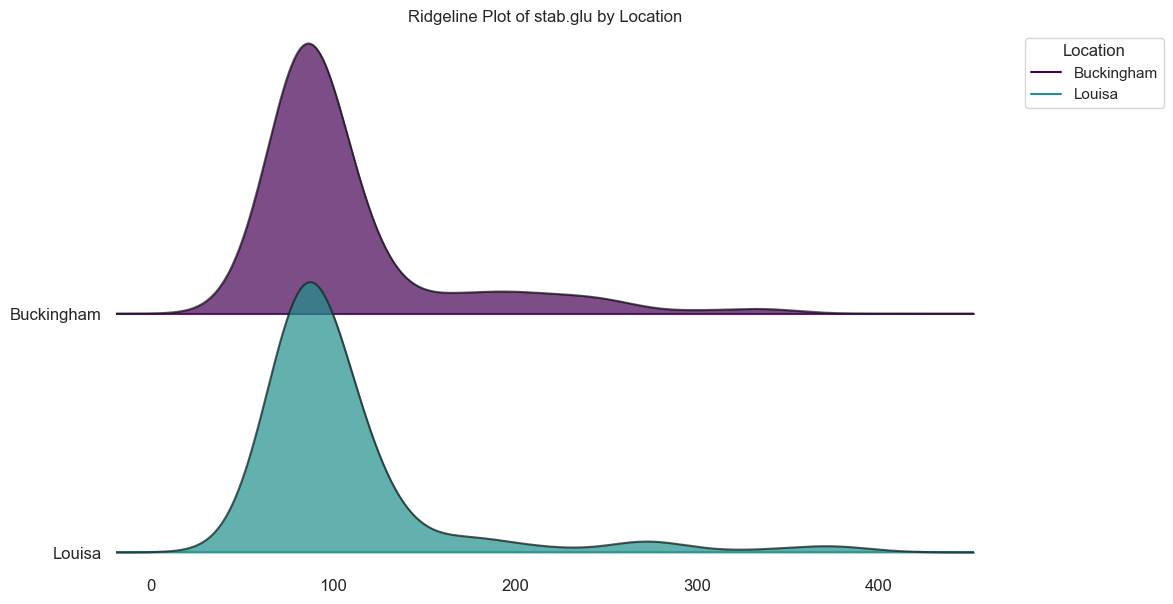

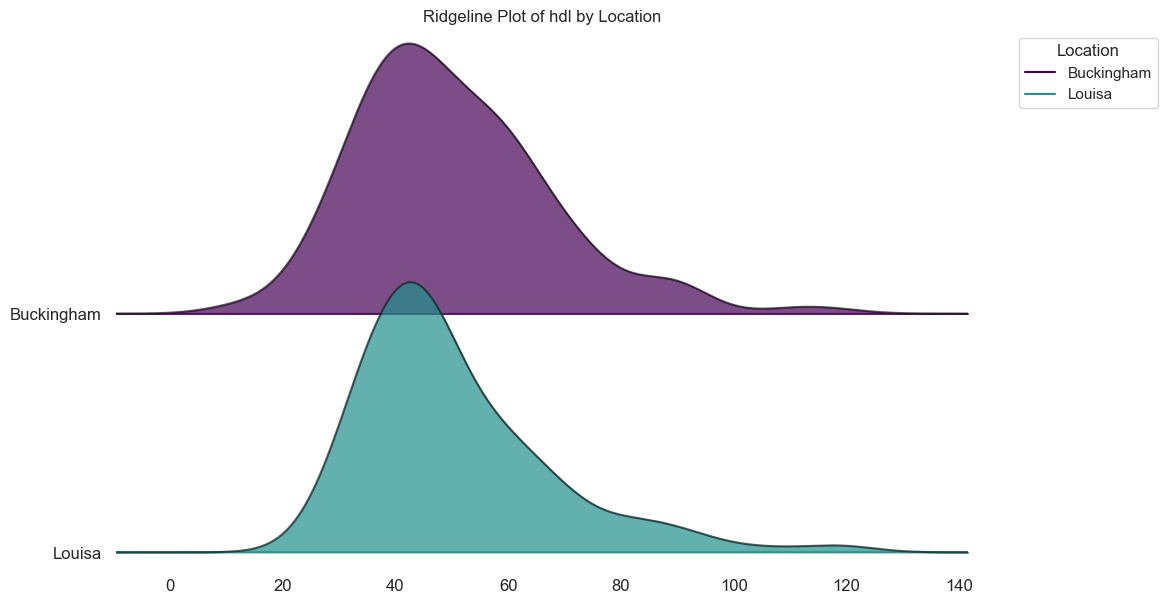

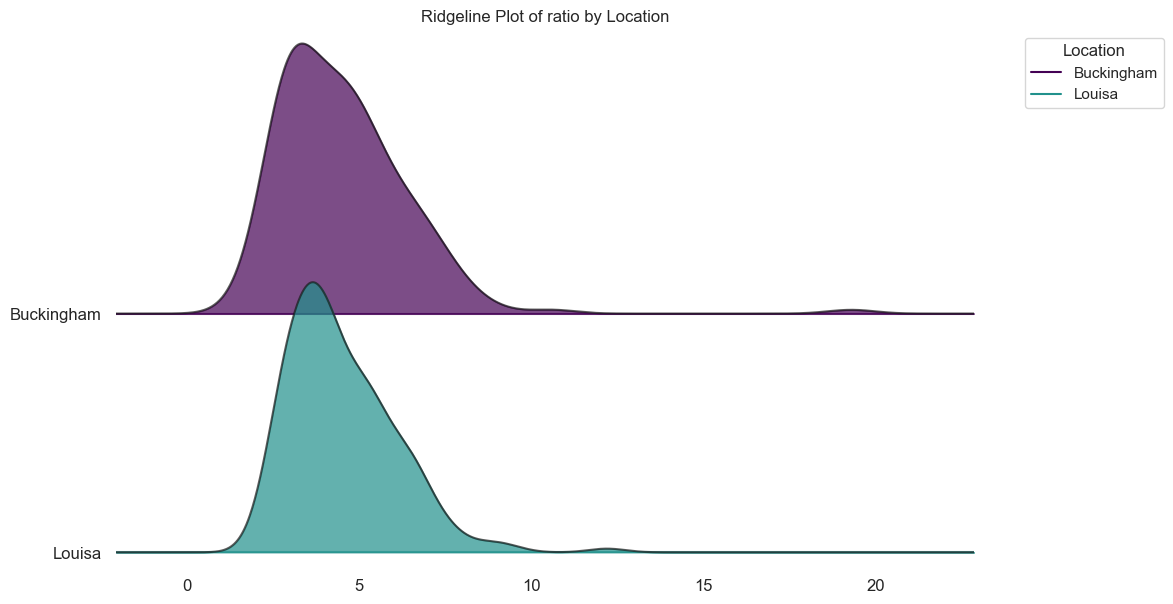

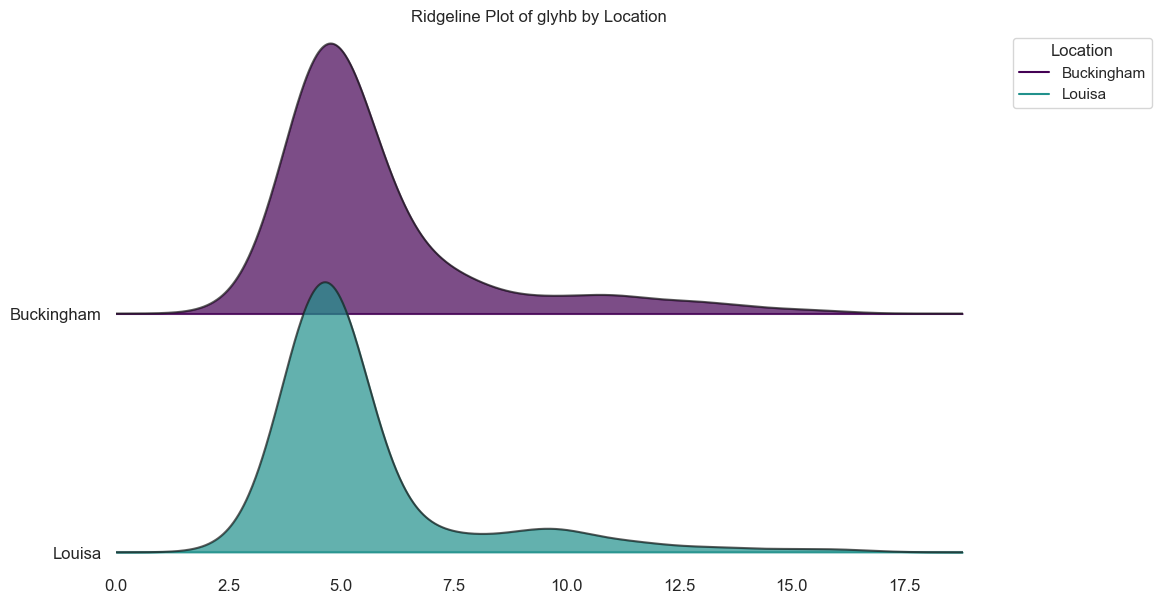

In [77]:
from joypy import joyplot
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Categories included in the plot:
measures = ["chol", "stab.glu", "hdl", "ratio", "glyhb"]

# Define a colormap (e.g., 'tab10', 'Set2', etc.)
colormap = cm.get_cmap('viridis')  # You can replace 'tab10' with another colormap

# Loop through each measure and create a ridgeline plot
for measure in measures:
    fig, axes = joyplot(
        data,
        by="location",
        column=[measure],
        ylim="own",
        figsize=(10, 6),
        alpha=0.7,
        overlap=0.7,
        colormap=colormap,  # Apply the colormap to assign different colors to locations
        legend=False  # Disable the default legend
    )
    
    # Add a custom legend for locations
    unique_locations = data['location'].unique()  # Get unique locations
    colors = [colormap(i / len(unique_locations)) for i in range(len(unique_locations))]  # Generate colors
    for loc, color in zip(unique_locations, colors):
        plt.plot([], [], color=color, label=loc)  # Create dummy plots for legend entries
    
    plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')  # Add legend outside the plot
    
    # Add title and adjust layout for better visualization
    plt.title(f"Ridgeline Plot of {measure} by Location")
    plt.show()


In [ ]:
# Q2: 